In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, classification_report
import joblib

print('Imports ready')

Imports ready


In [2]:
df = pd.read_csv('fraud_anomaly.csv')
print('Shape:', df.shape)

Shape: (5000, 5)


In [3]:
print('\nClass distribution:')
print(df['is_anomaly'].value_counts())
df.head()


Class distribution:
is_anomaly
0    4773
1     227
Name: count, dtype: int64


,transaction_amt,transaction_hour,merchant_risk,velocity,is_anomaly
0,3.062212,10,0.368691,0.346900,0
1,49.946435,4,0.869817,8.453126,0
2,9.368144,8,0.366455,1.175279,0
3,17.279756,7,0.474305,1.559105,0
4,16.201447,8,0.442106,7.566017,0


In [4]:
print('Dataset info:')
df.info()

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_amt   5000 non-null   float64
 1   transaction_hour  5000 non-null   int64  
 2   merchant_risk     5000 non-null   float64
 3   velocity          5000 non-null   float64
 4   is_anomaly        5000 non-null   int64  
dtypes: float64(3), int64(2)
memory usage: 195.4 KB


In [5]:
print('\nMissing values per column:')
print(df.isnull().sum())


Missing values per column:
transaction_amt     0
transaction_hour    0
merchant_risk       0
velocity            0
is_anomaly          0
dtype: int64


In [6]:
print('\nDescriptive statistics:')
display(df.describe())


Descriptive statistics:


,transaction_amt,transaction_hour,merchant_risk,velocity,is_anomaly
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,33.522063,11.514800,0.501150,4.975234,0.045400
std,42.263306,6.987413,0.287091,2.899995,0.208201
min,0.486544,0.000000,0.000477,0.002898,0.000000
25%,10.183707,5.000000,0.254284,2.453210,0.000000
50%,20.572406,12.000000,0.498642,4.968678,0.000000
75%,40.186028,18.000000,0.748805,7.456669,0.000000
max,639.427595,23.000000,0.999701,9.992538,1.000000


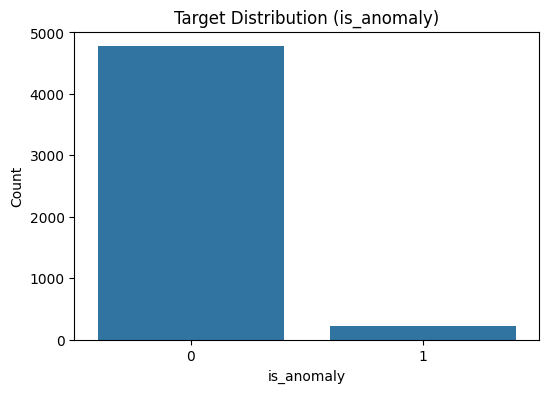

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='is_anomaly', data=df)
plt.title('Target Distribution (is_anomaly)')
plt.xlabel('is_anomaly')
plt.ylabel('Count')
plt.show()

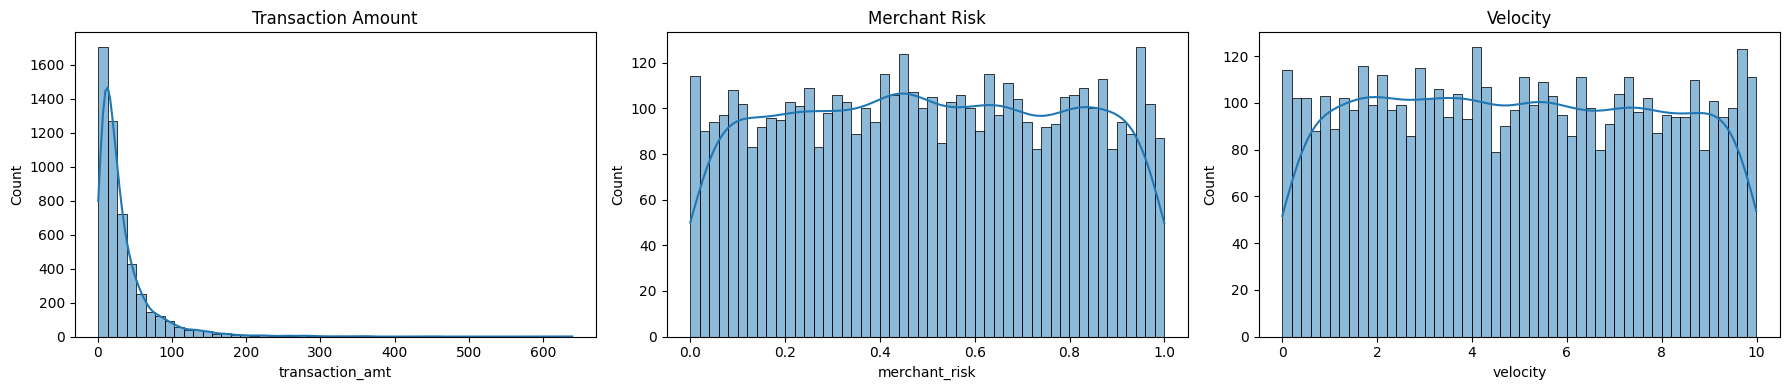

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18,4))
sns.histplot(df['transaction_amt'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Transaction Amount')

sns.histplot(df['merchant_risk'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Merchant Risk')

sns.histplot(df['velocity'], bins=50, kde=True, ax=axes[2])
axes[2].set_title('Velocity')

plt.tight_layout()
plt.show()

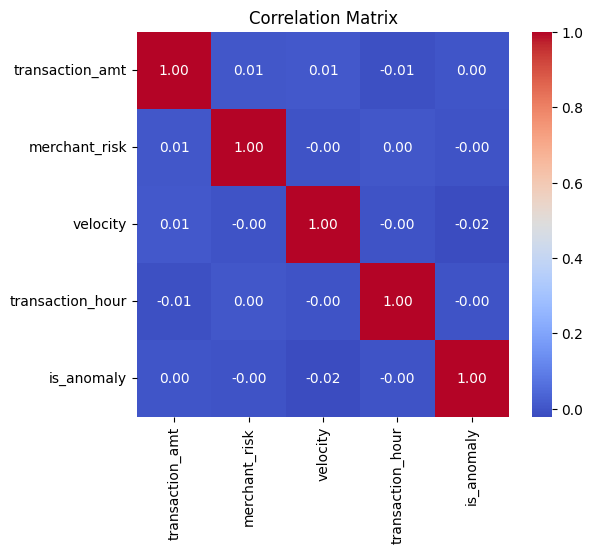

In [9]:
corr = df[ ['transaction_amt','merchant_risk','velocity','transaction_hour','is_anomaly'] ].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

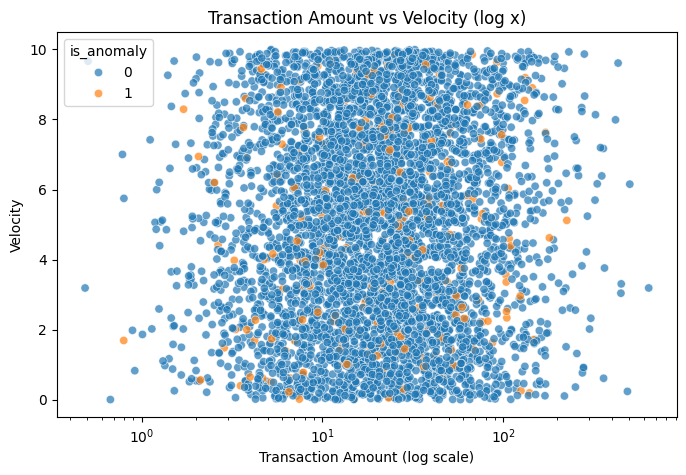

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='transaction_amt', y='velocity', hue='is_anomaly', data=df, alpha=0.7)
plt.xscale('log')
plt.title('Transaction Amount vs Velocity (log x)')
plt.xlabel('Transaction Amount (log scale)')
plt.ylabel('Velocity')
plt.show()

In [11]:
if 'hour_sin' not in df.columns:
    df['hour_sin'] = np.sin(2 * np.pi * df['transaction_hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['transaction_hour'] / 24)

features = ['transaction_amt', 'merchant_risk', 'velocity', 'hour_sin', 'hour_cos']
X = df[features]
y = df['is_anomaly']
print('Features selected:', features)

Features selected: ['transaction_amt', 'merchant_risk', 'velocity', 'hour_sin', 'hour_cos']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print('Train:', X_train.shape, 'Test:', X_test.shape)
print('Train class distribution:', np.bincount(y_train))
print('Test class distribution:', np.bincount(y_test))

Train: (4000, 5) Test: (1000, 5)
Train class distribution: [3818  182]
Test class distribution: [955  45]


In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Scaling complete')

Scaling complete


In [14]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)
print('Balanced train shape:', X_train_bal.shape)
print('Balanced class counts:', np.bincount(y_train_bal))

Balanced train shape: (7636, 5)
Balanced class counts: [3818 3818]


In [15]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=500, class_weight='balanced', random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    'SVM': SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5,
                                use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
}
print('Models defined:', list(models.keys()))

Models defined: ['LogisticRegression', 'RandomForest', 'SVM', 'XGBoost']


In [16]:
for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    print('Trained:', name)

Trained: LogisticRegression
Trained: RandomForest
Trained: SVM
Trained: XGBoost


In [17]:
results = []
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    results.append({
        'model': name, 'precision': prec, 'recall': rec, 'f1': f1, 'roc_auc': auc,
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)
    })

metrics_df = pd.DataFrame(results).set_index('model')
metrics_df[['precision','recall','f1','roc_auc']]

,precision,recall,f1,roc_auc
model,,,,
LogisticRegression,0.044543,0.444444,0.080972,0.476533
RandomForest,0.064516,0.044444,0.052632,0.546992
SVM,0.042553,0.355556,0.076010,0.486888
XGBoost,0.061538,0.088889,0.072727,0.550006


In [18]:
from IPython.display import display

display(metrics_df.style.format({
    'precision':'{:.4f}','recall':'{:.4f}','f1':'{:.4f}','roc_auc':'{:.4f}'
}))

for name in metrics_df.index:
    print(f"\n{name} classification report:")
    y_pred = models[name].predict(X_test_scaled)
    print(classification_report(y_test, y_pred, zero_division=0))

,precision,recall,f1,roc_auc,tn,fp,fn,tp
model,,,,,,,,
LogisticRegression,0.0445,0.4444,0.0810,0.4765,526,429,25,20
RandomForest,0.0645,0.0444,0.0526,0.5470,926,29,43,2
SVM,0.0426,0.3556,0.0760,0.4869,595,360,29,16
XGBoost,0.0615,0.0889,0.0727,0.5500,894,61,41,4



LogisticRegression classification report:
              precision    recall  f1-score   support

           0       0.95      0.55      0.70       955
           1       0.04      0.44      0.08        45

    accuracy                           0.55      1000
   macro avg       0.50      0.50      0.39      1000
weighted avg       0.91      0.55      0.67      1000


RandomForest classification report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       955
           1       0.06      0.04      0.05        45

    accuracy                           0.93      1000
   macro avg       0.51      0.51      0.51      1000
weighted avg       0.92      0.93      0.92      1000


SVM classification report:
              precision    recall  f1-score   support

           0       0.95      0.62      0.75       955
           1       0.04      0.36      0.08        45

    accuracy                           0.61      1000
   macro avg       0

<Figure size 1000x500 with 0 Axes>

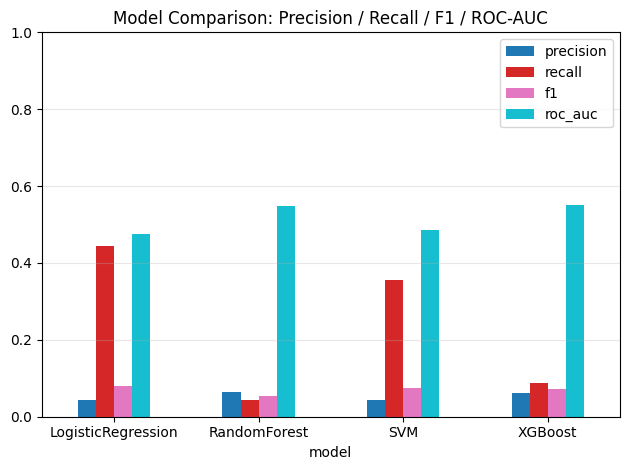

In [19]:
plt.figure(figsize=(10,5))
metrics_to_plot = ['precision','recall','f1','roc_auc']
metrics_df[metrics_to_plot].plot(kind='bar', rot=0, colormap='tab10')
plt.ylim(0,1)
plt.title('Model Comparison: Precision / Recall / F1 / ROC-AUC')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

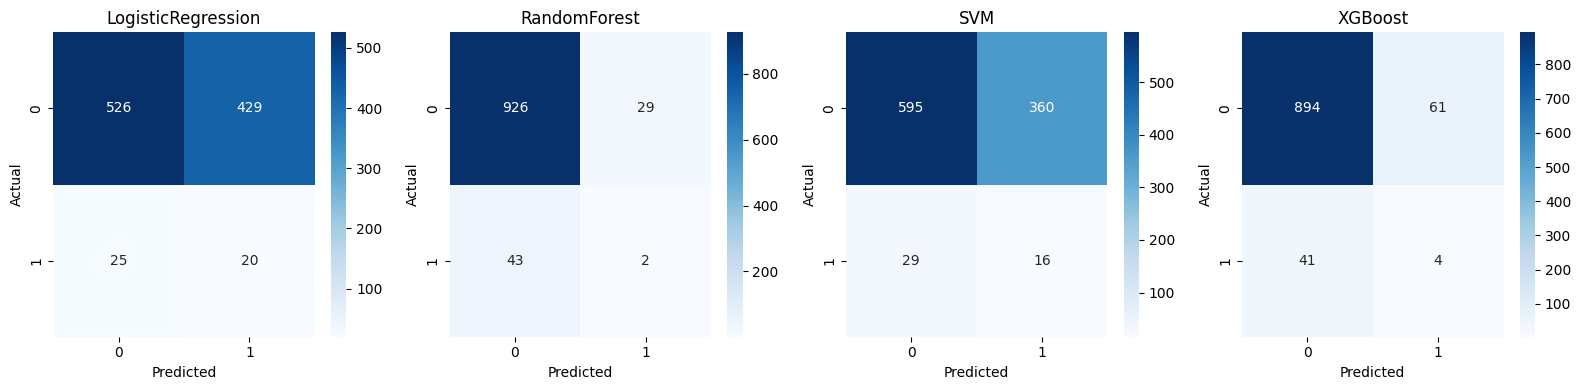

In [20]:
fig, axes = plt.subplots(1, len(metrics_df), figsize=(4*len(metrics_df),4))
if len(metrics_df)==1:
    axes=[axes]
for ax, name in zip(axes, metrics_df.index):
    cm = np.array([[metrics_df.loc[name,'tn'], metrics_df.loc[name,'fp']],
                   [metrics_df.loc[name,'fn'], metrics_df.loc[name,'tp']]])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

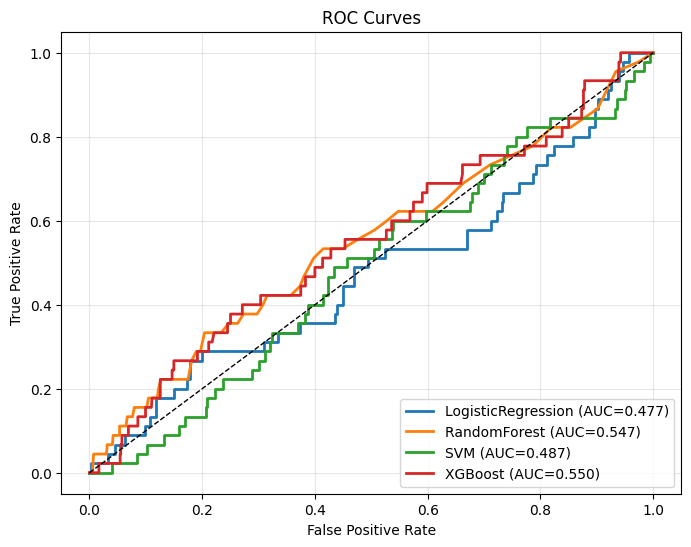

In [21]:
plt.figure(figsize=(8,6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={roc_auc_score(y_test, y_proba):.3f})")
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [22]:
best_by_f1 = metrics_df['f1'].idxmax()
best_by_auc = metrics_df['roc_auc'].idxmax()

print(f"Best by F1: {best_by_f1} ({metrics_df.loc[best_by_f1,'f1']:.4f})")
print(f"Best by ROC-AUC: {best_by_auc} ({metrics_df.loc[best_by_auc,'roc_auc']:.4f})\n")

if best_by_f1 == best_by_auc:
    print(f"Verdict: {best_by_f1} is the top model by both F1 and ROC-AUC.")
else:
    print("Metrics differ — select based on business need (Recall vs Precision).")
    print(f" - Higher recall: {metrics_df['recall'].idxmax()} ({metrics_df['recall'].max():.4f})")
    print(f" - Higher precision: {metrics_df['precision'].idxmax()} ({metrics_df['precision'].max():.4f})")

joblib.dump(models[best_by_f1], f'best_model_{best_by_f1}.joblib')
joblib.dump(scaler, 'scaler.joblib')
print(f"\nSaved best model to best_model_{best_by_f1}.joblib and scaler.joblib")

Best by F1: LogisticRegression (0.0810)
Best by ROC-AUC: XGBoost (0.5500)

Metrics differ — select based on business need (Recall vs Precision).
 - Higher recall: LogisticRegression (0.4444)
 - Higher precision: RandomForest (0.0645)

Saved best model to best_model_LogisticRegression.joblib and scaler.joblib
